In [1]:
import pandas as pd
import numpy as np
from google.colab import files

rng = np.random.default_rng(12)
products = {
    "Electronics": ("Headphones", 2400),
    "Clothing": ("T-shirt", 850),
    "Groceries": ("Food basket", 650),
}

rows = []
for month in range(1, 13):
    for category, (product, base_price) in products.items():
        for order in range(3):
            rows.append({
                "product": product,
                "category": category,
                "date": f"2025-{month:02d}-{order * 7 + 5:02d}",
                "sales_amount": int(base_price + month * 35
                                    + rng.integers(-150, 151))
            })

sales = pd.DataFrame(rows)
sales.to_csv("v12.csv", index=False)
display(sales.head())
files.download("v12.csv")

,product,category,date,sales_amount
0,Headphones,Electronics,2025-01-05,2469
1,Headphones,Electronics,2025-01-12,2360
2,Headphones,Electronics,2025-01-19,2577
3,T-shirt,Clothing,2025-01-05,1019
4,T-shirt,Clothing,2025-01-12,754


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

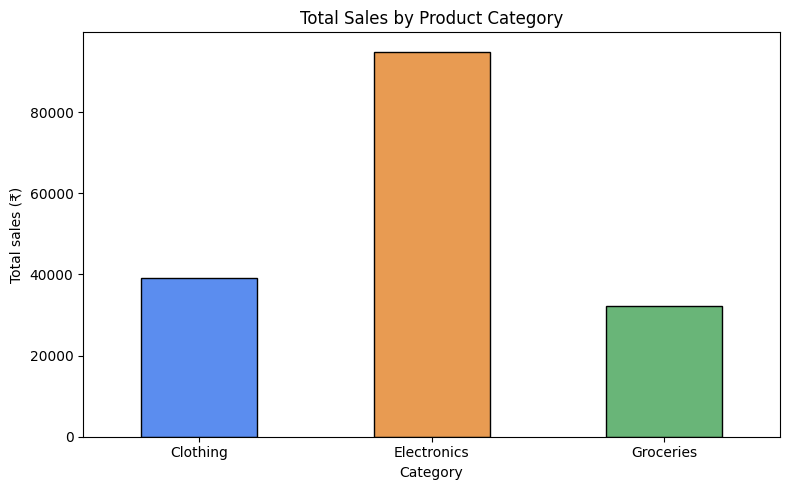

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

sales = pd.read_csv("v12.csv")
category_totals = sales.groupby("category")["sales_amount"].sum()

ax = category_totals.plot.bar(
    figsize=(8, 5),
    color=["#5B8DEF", "#E89B52", "#69B578"],
    edgecolor="black"
)
ax.set_title("Total Sales by Product Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total sales (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

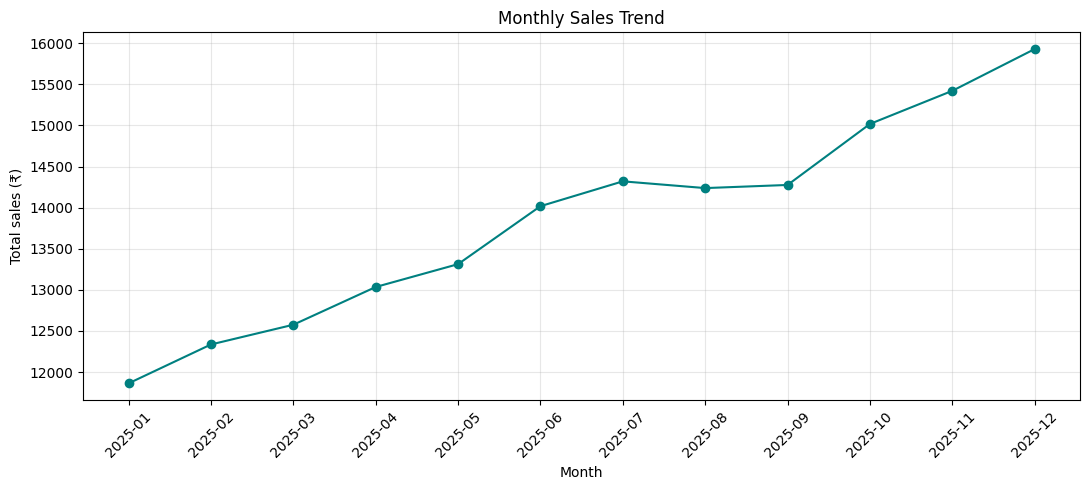

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

sales = pd.read_csv("v12.csv", parse_dates=["date"])
sales["month"] = sales["date"].dt.to_period("M")
monthly_totals = sales.groupby("month")["sales_amount"].sum()

plt.figure(figsize=(11, 5))
plt.plot(monthly_totals.index.astype(str),
         monthly_totals.values, marker="o", color="teal")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total sales (₹)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

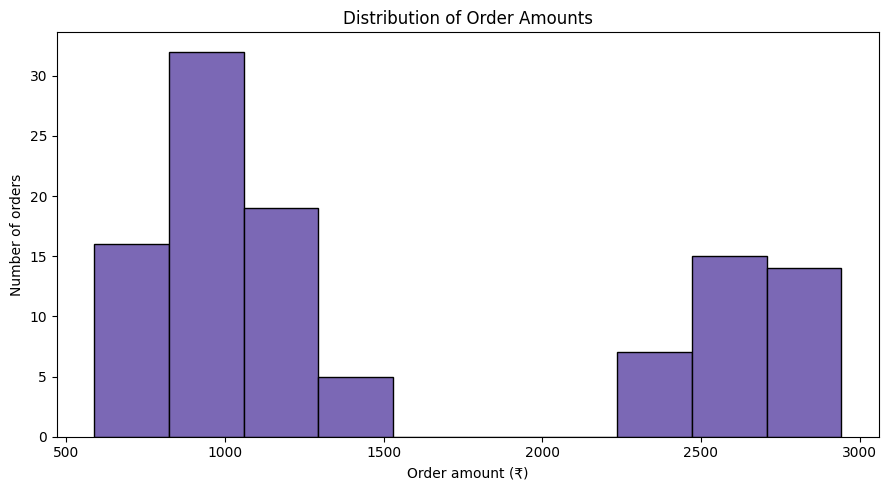

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

sales = pd.read_csv("v12.csv")

plt.figure(figsize=(9, 5))
plt.hist(sales["sales_amount"], bins=10,
         color="#7B68B5", edgecolor="black")
plt.title("Distribution of Order Amounts")
plt.xlabel("Order amount (₹)")
plt.ylabel("Number of orders")
plt.tight_layout()
plt.show()

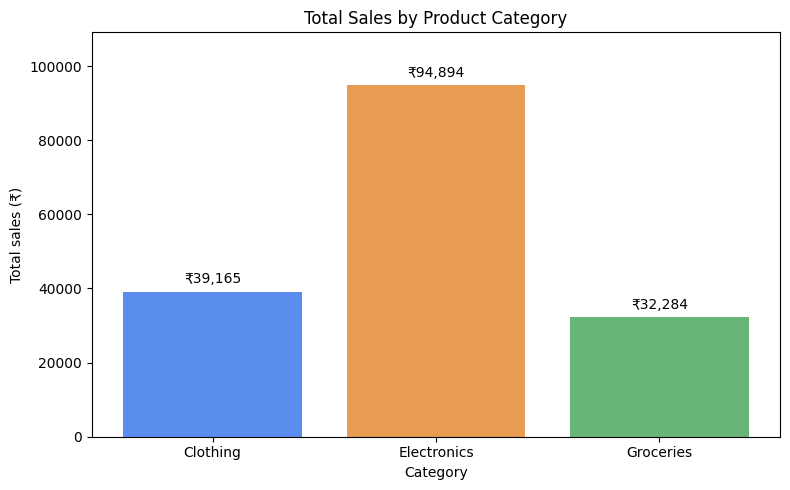

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

sales = pd.read_csv("v12.csv")
totals = sales.groupby("category")["sales_amount"].sum()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(totals.index, totals.values,
              color=["#5B8DEF", "#E89B52", "#69B578"])

ax.bar_label(
    bars,
    labels=[f"₹{amount:,.0f}" for amount in totals.values],
    padding=4
)
ax.set_ylim(0, totals.max() * 1.15)
ax.set_title("Total Sales by Product Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total sales (₹)")
fig.tight_layout()

fig.savefig("category_sales_kpi.png", dpi=150)
plt.show()
files.download("category_sales_kpi.png")